In [1]:
from src.plots import plot_decision_tree, plot_feature_importance, plot_model_comparison
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Preprocesamiento "rápido" para los baselines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# Métricas y validación
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configuración 
from src.utils import DEV_SET_CLEAN_PATH, TARGET, COLS

# Configuración de plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Modelos base _sin_ preprocesamiento
Hacemos un preprocesamiento _muy_ básico para que los modelos puedan funcionar

In [2]:
df = pd.read_csv("../" + DEV_SET_CLEAN_PATH)

COLS_TO_DROP = [
    "id_grid",         
    "mes_listing",     
    "year",             
    "ITE_ADD_CITY_NAME", 
    "ITE_ADD_NEIGHBORHOOD_NAME", 
]

X = df.drop(columns=[TARGET] + COLS_TO_DROP)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

In [3]:
def print_model_metrics(y_true, y_pred, model_name):
    """Imprime métricas de un modelo"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"=== Modelo: {model_name} ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    print("-" * 50)

### Pipeline Básico
Solo imputación & encoding

In [4]:
# Numéricas: Imputar mediana
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

# Categóricas: Imputar moda + Ordinal
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OrdinalEncoder())
])

# Preprocesador
base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

### 1.1 Dummy Regressor
Predice siempre la media

In [5]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print_model_metrics(y_test, y_pred_dummy, "Dummy Regressor")

=== Modelo: Dummy Regressor ===
RMSE: 681152.9130
MAE: 125955.5544
R2: -0.0000
--------------------------------------------------


### 1.2. Lasso Regression
Requiere un pipeline básico para que pueda funcionar

In [6]:
lasso_model = Pipeline([
    ('preprocessor', base_preprocessor),
    ('regressor', Lasso(alpha=1, random_state=42))
])

lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print_model_metrics(y_test, y_pred_lasso, "Lasso")

=== Modelo: Lasso ===
RMSE: 678912.1006
MAE: 120213.7725
R2: 0.0066
--------------------------------------------------


### 1.3. Decision Tree

=== Modelo: Decision Tree ===
RMSE: 666754.0966
MAE: 117732.5931
R2: 0.0418
--------------------------------------------------


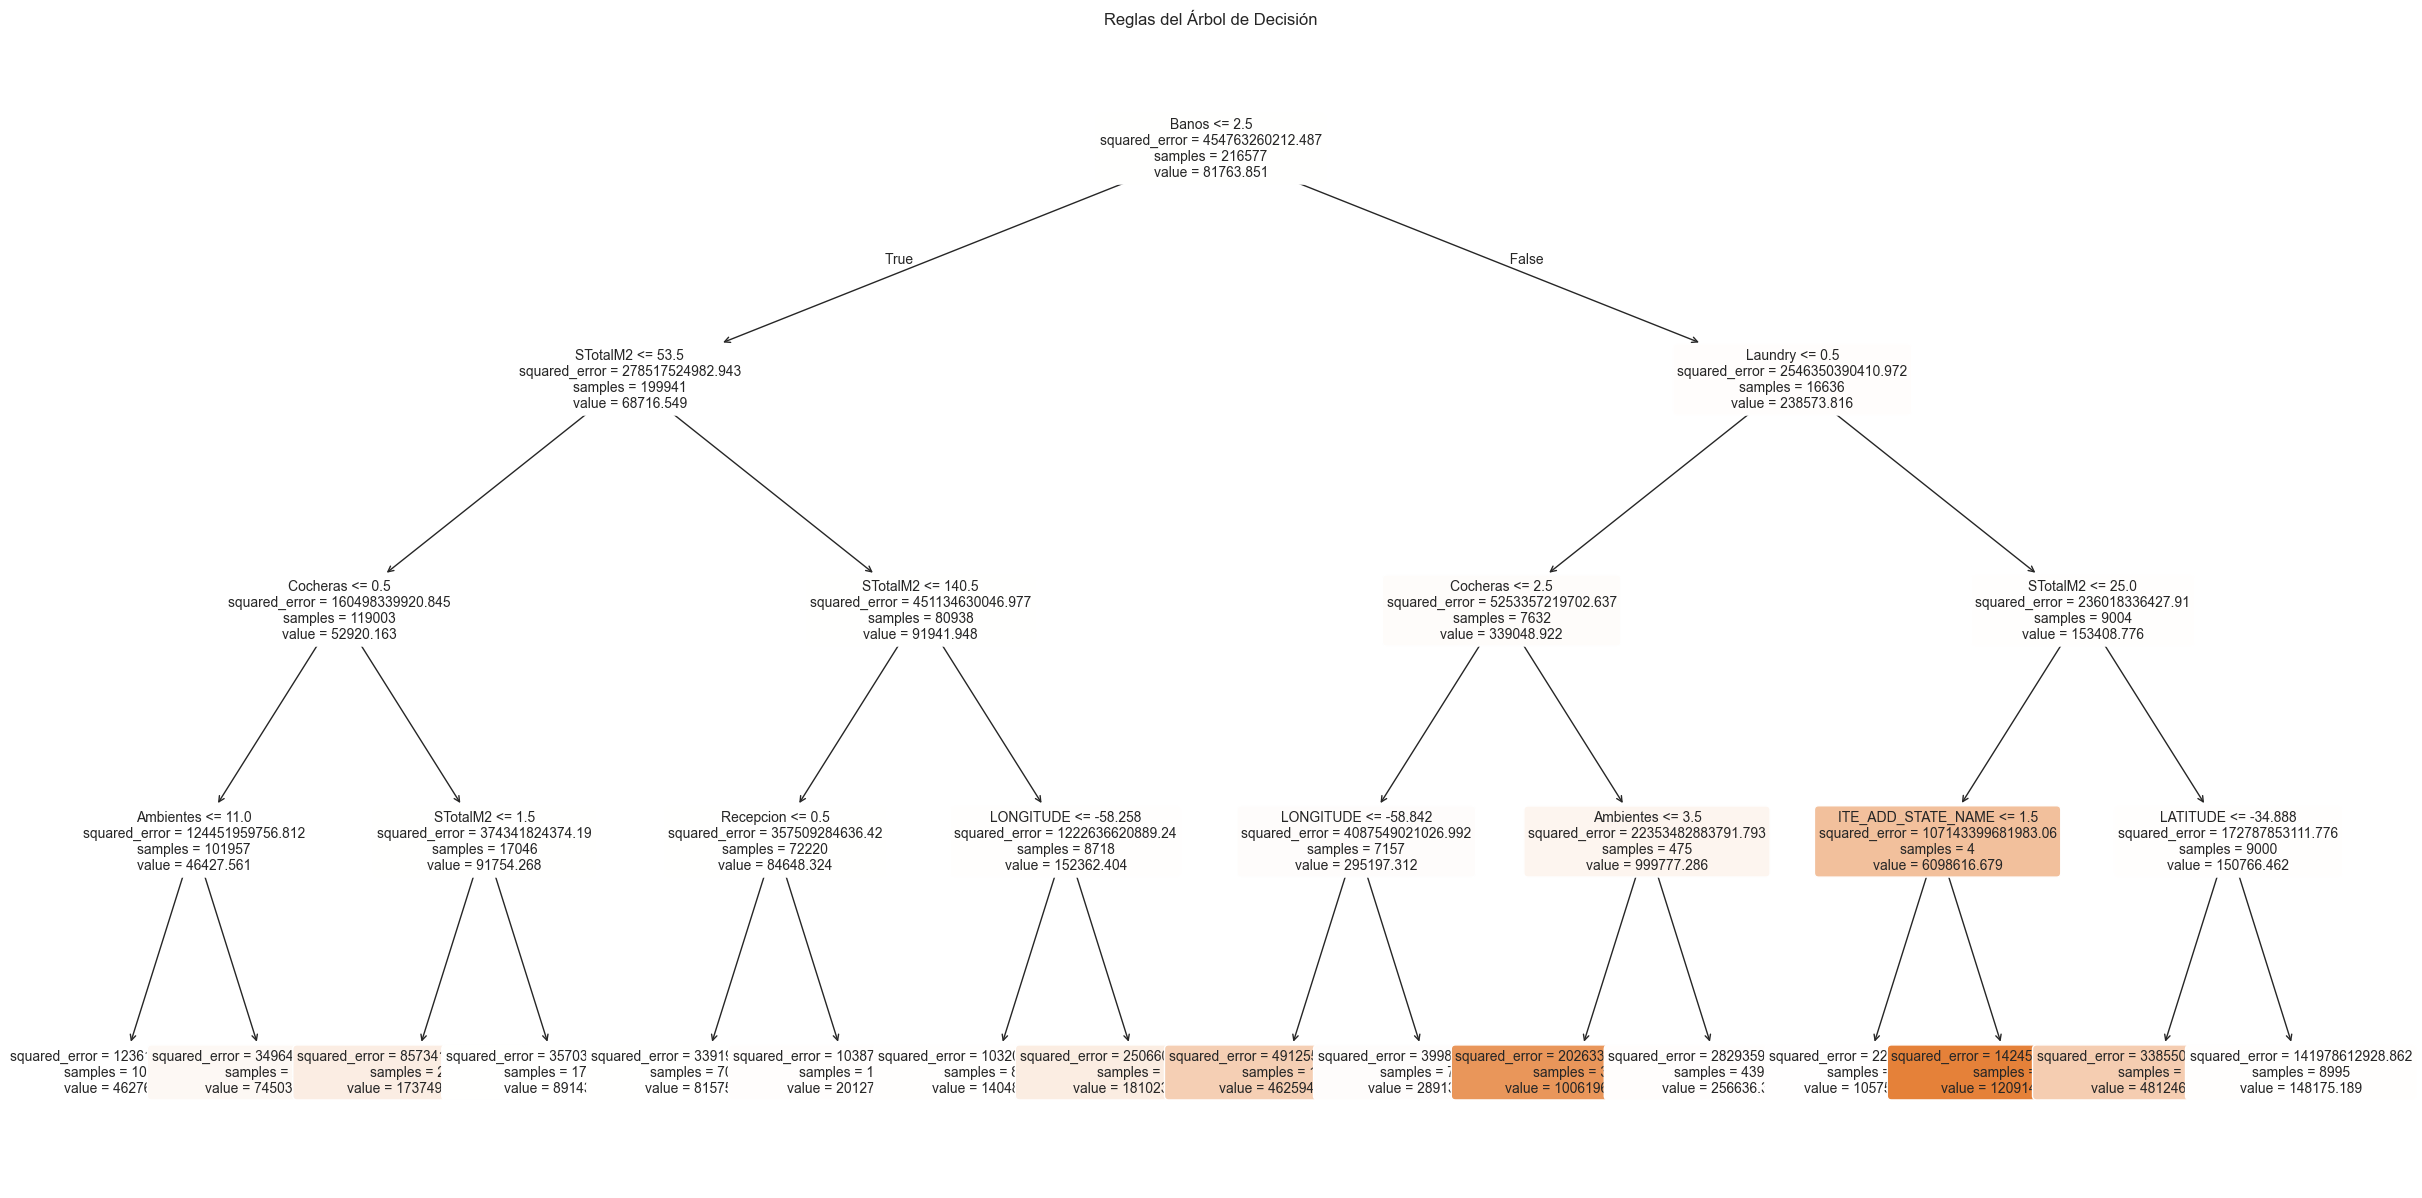

In [7]:
tree_model = Pipeline([
    ('preprocessor', base_preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=4, random_state=42))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print_model_metrics(y_test, y_pred_tree, "Decision Tree")
plot_decision_tree(tree_model, numeric_cols + categorical_cols, figsize=(30, 15))

### 1.4. XGBoost

In [8]:
xgb_model = Pipeline([
    ('preprocessor', base_preprocessor),
    ('regressor', XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1))
])

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print_model_metrics(y_test, y_pred_xgb, "XGBoost")

=== Modelo: XGBoost ===
RMSE: 428238.8778
MAE: 61731.5177
R2: 0.6047
--------------------------------------------------


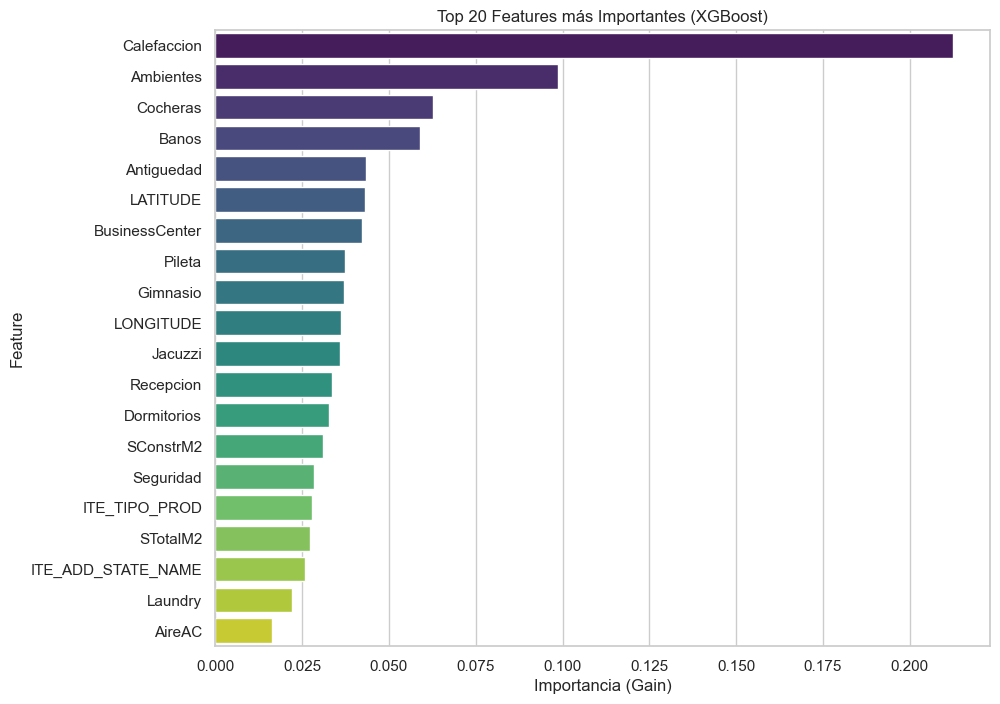

In [9]:
plot_feature_importance(xgb_model, numeric_cols + categorical_cols)

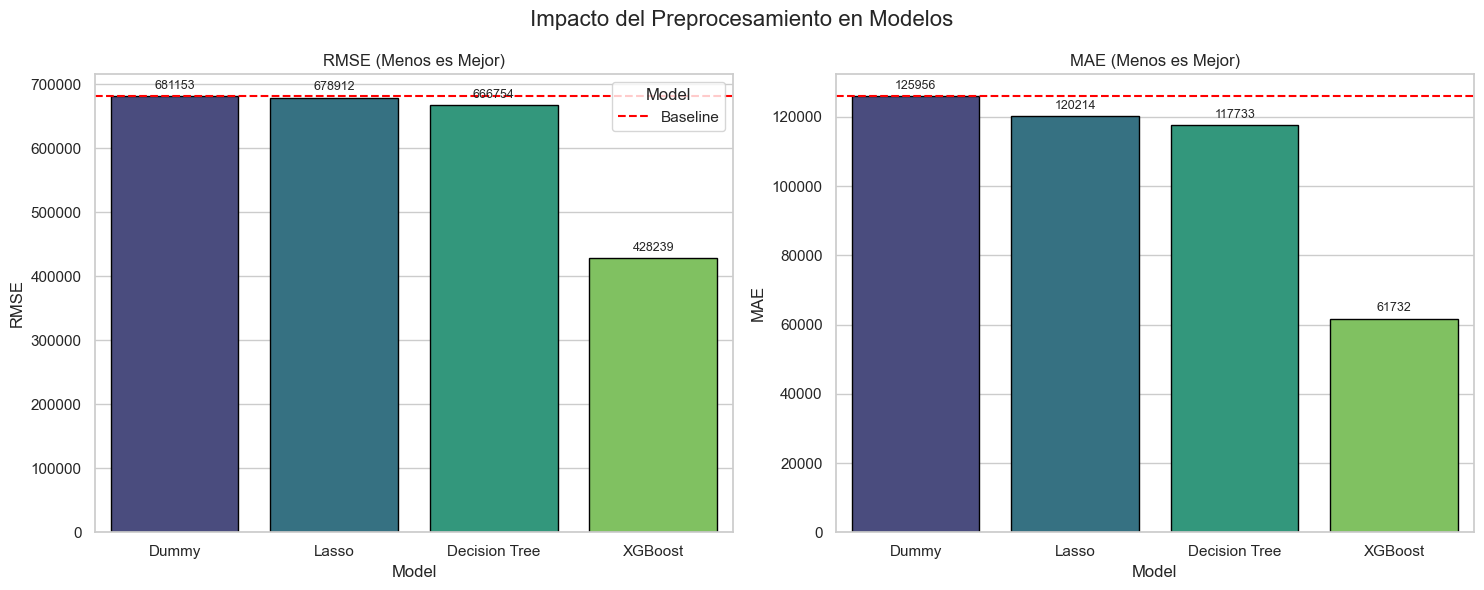

,Model,Variant,RMSE,MAE,R2,MAPE
0,Dummy,Raw,681152.912984,125955.554357,-0.000008,8.174219
1,Lasso,Raw,678912.100559,120213.772529,0.006561,6.559214
2,Decision Tree,Raw,666754.096623,117732.593123,0.041823,6.117475
3,XGBoost,Raw,428238.877820,61731.517707,0.604737,4.381016


In [10]:
models_predictions = {
    'model': ['Dummy', 'Lasso', 'Decision Tree', 'XGBoost'],
    'y_pred': [y_pred_dummy, y_pred_lasso, y_pred_tree, y_pred_xgb],
    'y_test': y_test,
}

plot_model_comparison(models_predictions)

# 2. Modelos base _con_ pipeline de preprocesamiento

Preparamos los pipelines

In [11]:
from src.config import linear_models_pipeline_config, decision_trees_pipeline_config
from src.pipeline import build_feature_pipeline, build_target_pipeline
from sklearn.compose import TransformedTargetRegressor

In [12]:
df_clean = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X_pipe = df_clean.drop(columns=[COLS.TARGET]) # excluimos estas columnas porque todavía no están preprocesadas!!!
y_pipe = df_clean[[COLS.TARGET]]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pipe, y_pipe, test_size=0.2, random_state=42)


### 2.1 Lasso Regression

In [13]:
linear_feature_pipeline = build_feature_pipeline(linear_models_pipeline_config)
linear_target_pipeline = build_target_pipeline(linear_models_pipeline_config)

lasso_pipe_model = TransformedTargetRegressor(
    regressor=Lasso(alpha=0.01, random_state=42),
    transformer=linear_target_pipeline,
    check_inverse=False
)

full_lasso = Pipeline([
    ('preprocessor', linear_feature_pipeline),
    ('model', lasso_pipe_model)
])

# Nota: Al usar func/inverse, no clipeamos el target automáticamente.
# Si los outliers son muy graves, el log igual ayuda mucho.
full_lasso.fit(X_train_p, y_train_p)
y_pred_lasso_p = full_lasso.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_lasso_p, "Lasso (Preprocesado)")


/Users/gonza/Documents/Gonza/UdeSA/05-machine-learning/alquileres/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== Modelo: Lasso (Preprocesado) ===
RMSE: 682525.5054
MAE: 68347.9776
R2: -0.0040
--------------------------------------------------


In [14]:
tree_feature_pipeline = build_feature_pipeline(decision_trees_pipeline_config)
tree_target_pipeline = build_target_pipeline(decision_trees_pipeline_config)

decision_tree_p = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(max_depth=4, random_state=42),
    transformer=tree_target_pipeline,
    check_inverse=False
)

full_tree = Pipeline([
    ('preprocessor', tree_feature_pipeline),
    ('model', decision_tree_p)
])

full_tree.fit(X_train_p, y_train_p)
y_pred_tree_p = full_tree.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_tree_p, "Decision Tree (Preprocesado)")

=== Modelo: Decision Tree (Preprocesado) ===
RMSE: 682786.0335
MAE: 69485.3957
R2: -0.0048
--------------------------------------------------


In [15]:
xgb_regressor_p = TransformedTargetRegressor(
    regressor=XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=10, random_state=42, n_jobs=-1),
    transformer=tree_target_pipeline,
    check_inverse=False
)

full_xgb = Pipeline([
    ('preprocessor', tree_feature_pipeline),
    ('model', xgb_regressor_p)
])

full_xgb.fit(X_train_p, y_train_p)
y_pred_xgb_p = full_xgb.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_xgb_p, "XGBoost (Preprocesado)")

=== Modelo: XGBoost (Preprocesado) ===
RMSE: 503611.5227
MAE: 43047.2031
R2: 0.4534
--------------------------------------------------


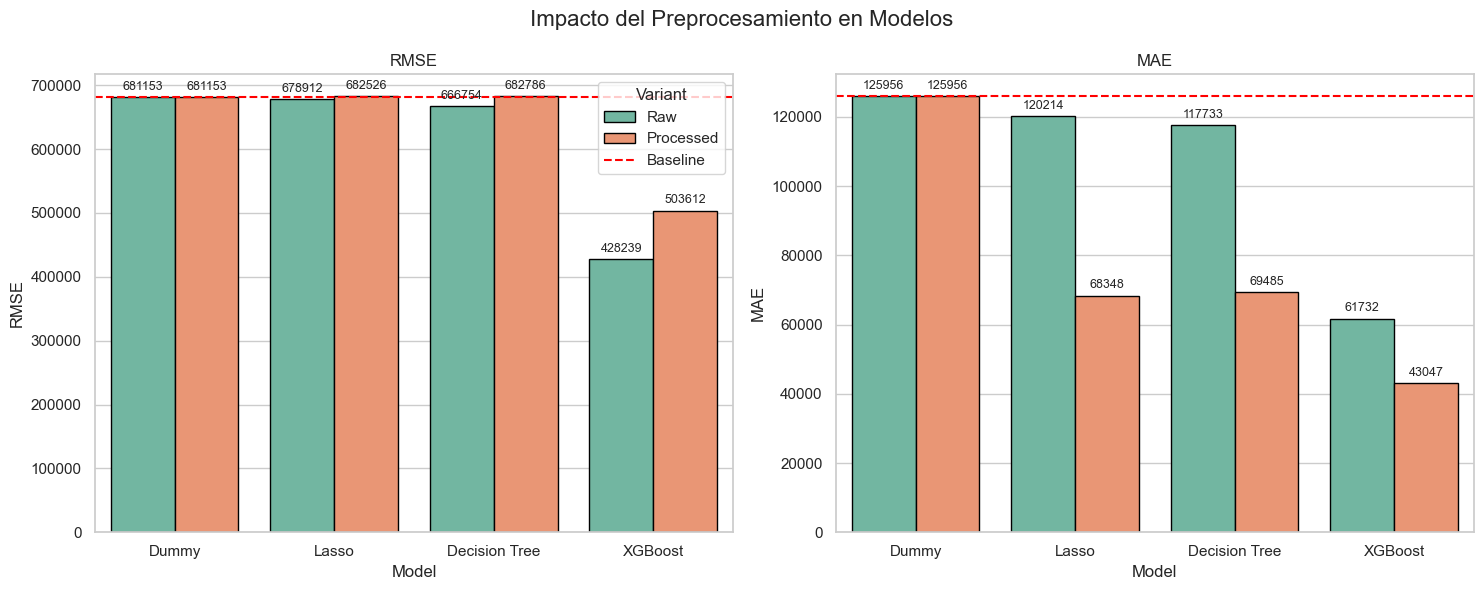

,Model,Variant,RMSE,MAE,R2,MAPE
0,Dummy,Raw,681152.912984,125955.554357,-0.000008,8.174219
1,Dummy,Processed,681152.912984,125955.554357,-0.000008,8.174219
2,Lasso,Raw,678912.100559,120213.772529,0.006561,6.559214
3,Lasso,Processed,682525.505399,68347.977627,-0.004042,0.374194
4,Decision Tree,Raw,666754.096623,117732.593123,0.041823,6.117475
5,Decision Tree,Processed,682786.033458,69485.395697,-0.004809,0.448000
6,XGBoost,Raw,428238.877820,61731.517707,0.604737,4.381016
7,XGBoost,Processed,503611.522664,43047.203125,0.453355,0.377519


In [17]:
models_predictions = {
    'model': ['Dummy', 'Lasso', 'Decision Tree', 'XGBoost'],
    'y_pred': [y_pred_dummy, y_pred_lasso, y_pred_tree, y_pred_xgb],
    'y_pred_processed': [y_pred_dummy, y_pred_lasso_p, y_pred_tree_p, y_pred_xgb_p],
    'y_test': y_test,
    'y_test_processed': y_test_p
}
plot_model_comparison(models_predictions)